In [2]:
# 1. Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix
import nltk
import re
import string
from wordcloud import WordCloud
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Pramit\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Pramit\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [10]:
# 2. Load Dataset
df = pd.read_csv("IMDB Dataset.csv")
df = df[['review', 'sentiment']]
df = df.dropna()
df.columns = ['text', 'sentiment']

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


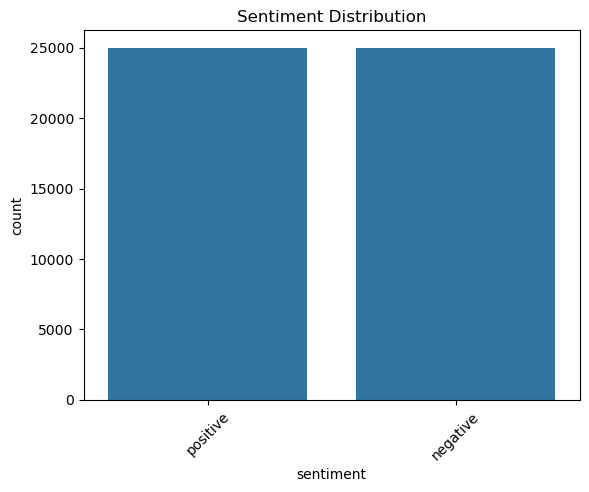

In [12]:
# 3. Basic EDA
print(df['sentiment'].value_counts())
sns.countplot(data=df, x='sentiment', order=df['sentiment'].value_counts().index)
plt.title("Sentiment Distribution")
plt.xticks(rotation=45)
plt.show()

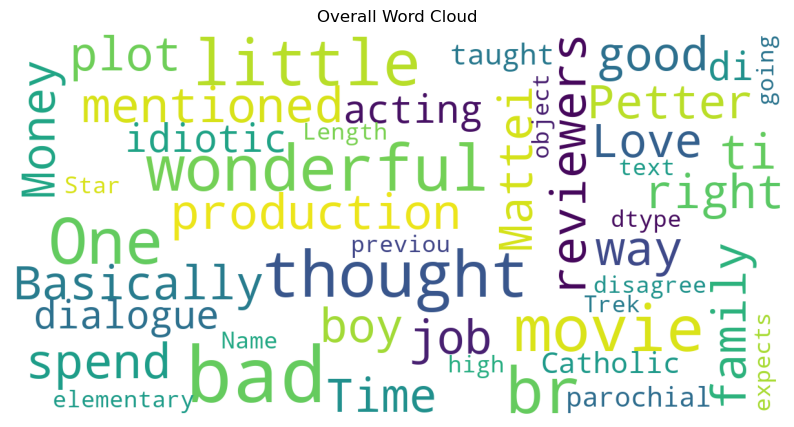

In [14]:
# Word Cloud Visualization
def show_wordcloud(data, title=None):
    wordcloud = WordCloud(
        background_color='white',
        max_words=200,
        max_font_size=40,
        scale=3,
        random_state=1
    ).generate(str(data))

    plt.figure(figsize=(10, 8))
    plt.imshow(wordcloud)
    plt.axis('off')
    if title: 
        plt.title(title)
    plt.show()

show_wordcloud(df['text'], title="Overall Word Cloud")


In [16]:
# 4. Text Preprocessing
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@[A-Za-z0-9_]+", "", text)
    text = re.sub(r"#[A-Za-z0-9_]+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stopwords.words('english') and len(t) > 2]
    return " ".join(tokens)


In [ ]:
df['clean_text'] = df['text'].apply(clean_text)

In [ ]:
# 5. Vectorization
vectorizer = TfidfVectorizer(max_features=3000)
X = vectorizer.fit_transform(df['clean_text'])
y = df['sentiment']


In [ ]:
# 6. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 7. Model Training and Comparison
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": LinearSVC()
}

In [ ]:
for name, model in models.items():
    print(f"\n===== {name} =====")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))
    conf_mat = confusion_matrix(y_test, y_pred)
    sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [ ]:
# 8. Sample Predictions using best model (e.g., SVM)
best_model = models["SVM"]
sample_texts = [
    "This movie was absolutely fantastic. A must-watch!",
    "Worst film I've ever seen. Total waste of time.",
    "It was okay, nothing too great or terrible."
]
sample_clean = [clean_text(t) for t in sample_texts]
sample_vec = vectorizer.transform(sample_clean)
sample_preds = best_model.predict(sample_vec)
for txt, pred in zip(sample_texts, sample_preds):
    print(f"Text: {txt}\nPredicted Sentiment: {pred}\n")

In [ ]:
'''  1. Dataset Overview
The dataset contains 50,000 reviews, evenly split between positive and negative sentiments.

There is no class imbalance, which simplifies modeling and avoids the need for resampling techniques.

2. Exploratory Data Analysis (EDA)
The sentiment distribution plot confirmed that the dataset is perfectly balanced.

The word cloud revealed that commonly occurring words include “movie,” “film,” “good,” “bad,” “like,” “story”, which align with movie-related vocabulary and sentiment indicators.

 3. Text Preprocessing
Text was cleaned through:

Lowercasing

Removal of URLs, mentions, hashtags, and non-alphabetic characters

Stopword removal and tokenization

Resulted in cleaned, noise-free text more suitable for machine learning.